#**Project Title**
#Crop Production Analysis in India using Python

#**Dataset information**

Source : Ministry of Agriculture & Farmers Welfare, Government of India

Location : India

Year/Timeline : 1997 - 2023

Domain: Agriculture Analytics

Granularity: District Level

Frequency: Yearly

Records: 45,539

Columns: 16

## **Problem Statement**

Agricultural production in India varies across different crops, states, districts and seasons. It is difficult to understand these variations from raw data alone. This project focuses on analyzing historical crop production data to identify production trends, major crops, high-performing regions and the relationship between cultivated area, production and yield.

# **Business Understanding**

The analysis aims to understand which crops, states, districts and seasons show better agricultural performance. The findings can be used to compare regional production, understand crop-wise performance and identify changes in agricultural production over time.

#**Objectives**
- To analyze year-wise crop production trends in India and identify how
agricultural production has changed over time.
- To identify the top-performing states and districts based on total crop production.
- To identify the major crops contributing to India's overall agricultural production.
- To compare crop production across different seasons such as Kharif, Rabi and other seasons.
- To analyze the relationship between cultivated area, production and yield for different crops.
- To identify high-yield and low-yield crops and understand their production patterns.
- To analyze state-wise and district-wise agricultural performance and identify regions with higher and lower productivity.
- To identify significant trends and patterns in crop production using exploratory data analysis and visualizations.
- To provide data-driven insights that can support agricultural planning and decision-making.


# **Initial EDA**

EDA = Exploratory Data Analysis

Initial EDA means understanding the dataset before cleaning and transformation.

# 1.Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2.Load Dataset

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Saving crop-wise-area-production-yield.csv to crop-wise-area-production-yield.csv
Dataset loaded successfully!
Dataset Shape: (455359, 16)


# 3. Check Dataset Shape

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (455359, 16)


# 4.Check Column Names

In [ ]:
print(df.columns.tolist())

['id', 'year', 'state_name', 'state_code', 'district_name', 'district_code', 'crop_name', 'crop_code', 'crop_type', 'season', 'area', 'area_unit', 'production', 'production_unit', 'yield', 'yield_unit']


# 5.Check Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455359 entries, 0 to 455358
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               455359 non-null  int64  
 1   year             455359 non-null  object 
 2   state_name       455359 non-null  object 
 3   state_code       455359 non-null  int64  
 4   district_name    455359 non-null  object 
 5   district_code    455359 non-null  int64  
 6   crop_name        455359 non-null  object 
 7   crop_code        455338 non-null  float64
 8   crop_type        455359 non-null  object 
 9   season           455359 non-null  object 
 10  area             455359 non-null  float64
 11  area_unit        455359 non-null  object 
 12  production       450350 non-null  float64
 13  production_unit  455359 non-null  object 
 14  yield            455359 non-null  float64
 15  yield_unit       455359 non-null  object 
dtypes: float64(4), int64(3), object(9)
mem

# 6.Check Missing Values

In [ ]:
print(df.isnull().sum())

id                    0
year                  0
state_name            0
state_code            0
district_name         0
district_code         0
crop_name             0
crop_code            21
crop_type             0
season                0
area                  0
area_unit             0
production         5009
production_unit       0
yield                 0
yield_unit            0
dtype: int64


# 7 . Check Duplicate Records

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# 8. Summary Statistics

In [ ]:
df.describe()

,id,state_code,district_code,crop_code,area,production,yield
count,455359.000000,455359.000000,455359.000000,455338.000000,4.553590e+05,4.503500e+05,455359.00000
mean,227679.000000,19.412593,359.423745,468.182563,1.313002e+04,8.380320e+05,68.84521
std,131450.964951,9.430053,185.520710,368.573998,4.846655e+04,2.028612e+07,861.71475
min,0.000000,1.000000,1.000000,101.000000,4.000000e-03,0.000000e+00,0.00000
25%,113839.500000,10.000000,193.000000,107.000000,7.900000e+01,9.100000e+01,0.56300
50%,227679.000000,21.000000,375.000000,288.000000,6.000000e+02,8.080000e+02,1.05100
75%,341518.500000,28.000000,520.000000,708.000000,4.777000e+03,8.350000e+03,2.55000
max,455358.000000,38.000000,765.000000,1503.000000,8.580100e+06,1.597800e+09,43958.33300


# 9 . Check Unique Values

In [ ]:
print("Unique Crops:", df['crop_name'].nunique())
print("Unique States:", df['state_name'].nunique())
print("Unique Districts:", df['district_name'].nunique())
print("Unique Seasons:", df['season'].nunique())

Unique Crops: 115
Unique States: 34
Unique Districts: 737
Unique Seasons: 7


# 10 . Initial Visualization
#Crop Production – Bar Chart

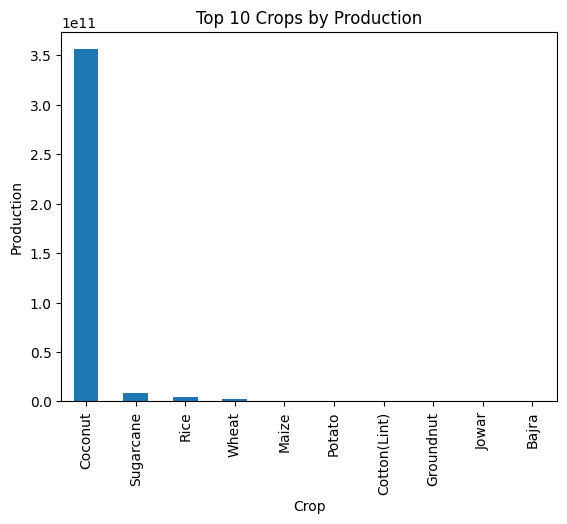

In [ ]:
df.groupby('crop_name')['production'].sum().nlargest(10).plot(kind='bar')
plt.title("Top 10 Crops by Production")
plt.xlabel("Crop")
plt.ylabel("Production")
plt.show()

# **Data Cleaning,Data Transformation  and Feature Engineering**

1. Handle duplicates

2. Handle missing values (impute or drop)

3. column name rename or dropping unwanted columns

4. Treat outliers if required(optional)

5. Convert data types if needed

6. Data Transformation or Data Wrangling

7. Final EDA


# 1. Handle Duplicates

In [ ]:
# Check and remove duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate Rows: 0


# 2. Handle Missing Values (Impute or Drop)
# Handle missing crop_code

In [ ]:
# Impute missing crop codes using mode
df['crop_code'] = df['crop_code'].fillna(
    df['crop_code'].mode()[0]
)

# Handle missing production

In [ ]:
# Remove rows with missing production
df = df.dropna(subset=['production'])

# Verify

In [ ]:
print("Remaining Missing Values:",
      df.isnull().sum().sum())

Remaining Missing Values: 0


# 3. Column Name Rename or Dropping Unwanted Columns

In [ ]:
print(df.columns.tolist())

['id', 'year', 'state_name', 'state_code', 'district_name', 'district_code', 'crop_name', 'crop_code', 'crop_type', 'season', 'area', 'area_unit', 'production', 'production_unit', 'yield', 'yield_unit']


# 4. Treat Outliers if Required (Optional)

In [ ]:
# Calculate IQR
Q1 = df['production'].quantile(0.25)
Q3 = df['production'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 91.0
Q3: 8350.0
IQR: 8259.0
Lower Limit: -12297.5
Upper Limit: 20738.5


# Potential outliers:

In [ ]:
outliers = df[
    (df['production'] < lower_limit) |
    (df['production'] > upper_limit)
]

print("Number of Production Outliers:", len(outliers))

Number of Production Outliers: 79643


# IQR meaning

IQR stands for Interquartile Range. It is calculated as Q3 minus Q1 and represents the middle 50% of the data.

# 5. Convert Data Types if Needed

In [ ]:
# Convert crop_code to integer
df['crop_code'] = df['crop_code'].astype(int)

print(df['crop_code'].dtype)

int64


# 6. Data Transformation or Data Wrangling

In [ ]:
1997-1998

In [ ]:
# Extract start and end years
df['start_year'] = df['year'].str[:4].astype(int)
df['end_year'] = df['year'].str[-4:].astype(int)

In [ ]:
| year      | start_year | end_year |
| --------- | ---------: | -------: |
| 1997-1998 |       1997 |     1998 |
| 1998-1999 |       1998 |     1999 |


# 7. Feature Engineering

**Feature Engineering** means creating new useful features from existing data.


 In this project, I created two new features:


>start_year

>end_year


from the existing year column.

In [ ]:
df['start_year'] = df['year'].str[:4].astype(int)
df['end_year'] = df['year'].str[-4:].astype(int)

# 8. Final EDA

After completing the cleaning and transformation, I performed final exploratory data analysis.

# Top 10 Crops by Production

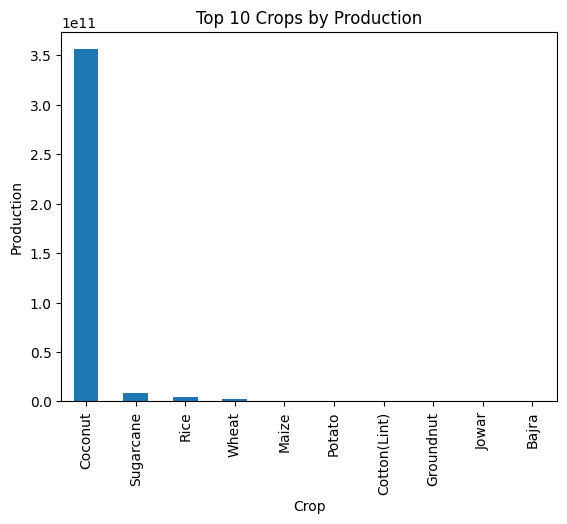

In [ ]:
top_crops = df.groupby('crop_name')['production'].sum().nlargest(10)

top_crops.plot(kind='bar')
plt.title("Top 10 Crops by Production")
plt.xlabel("Crop")
plt.ylabel("Production")
plt.show()

# Year-wise Production

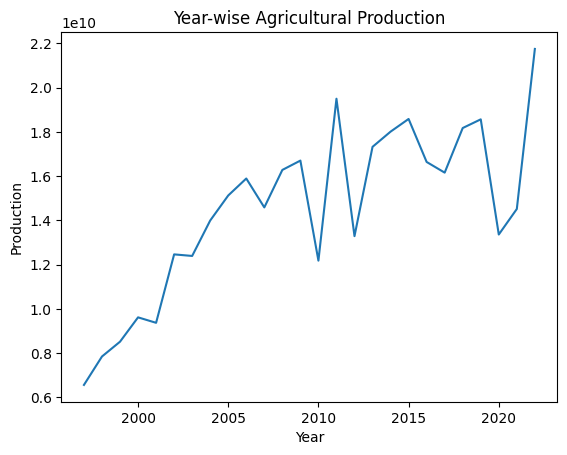

In [ ]:
yearly_production = df.groupby('start_year')['production'].sum()

yearly_production.plot(kind='line')
plt.title("Year-wise Agricultural Production")
plt.xlabel("Year")
plt.ylabel("Production")
plt.show()

# 9. Final Dataset Check

In [ ]:
print("Final Dataset Shape:", df.shape)
print("Final Columns:", df.columns.tolist())

Final Dataset Shape: (450350, 18)
Final Columns: ['id', 'year', 'state_name', 'state_code', 'district_name', 'district_code', 'crop_name', 'crop_code', 'crop_type', 'season', 'area', 'area_unit', 'production', 'production_unit', 'yield', 'yield_unit', 'start_year', 'end_year']


#

# **Statistical analysis & Visualizations**




# Statistical Analysis
-  Mean, Median, Mode

- Variance & Standard Deviation

- Skewness & Kurtosis

# Univariate Analysis – 3

- Production Distribution
- Crop Type Distribution
- Season Distribution

# Bivariate Analysis – 3

- Area vs Production
- Top 10 Crops by Production
- Season vs Production

# Multivariate Analysis – 2

- State + Crop + Production

- Year + Season + Production

# Part 1 – Statistical Analysis
# 1. Mean, Median and Mode





In [2]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print(df.shape)

Saving crop-wise-area-production-yield.csv to crop-wise-area-production-yield.csv
Dataset loaded successfully!
(455359, 16)


Mean Production   : 838031.98
Median Production : 808.0
Mode Production   : 1.0


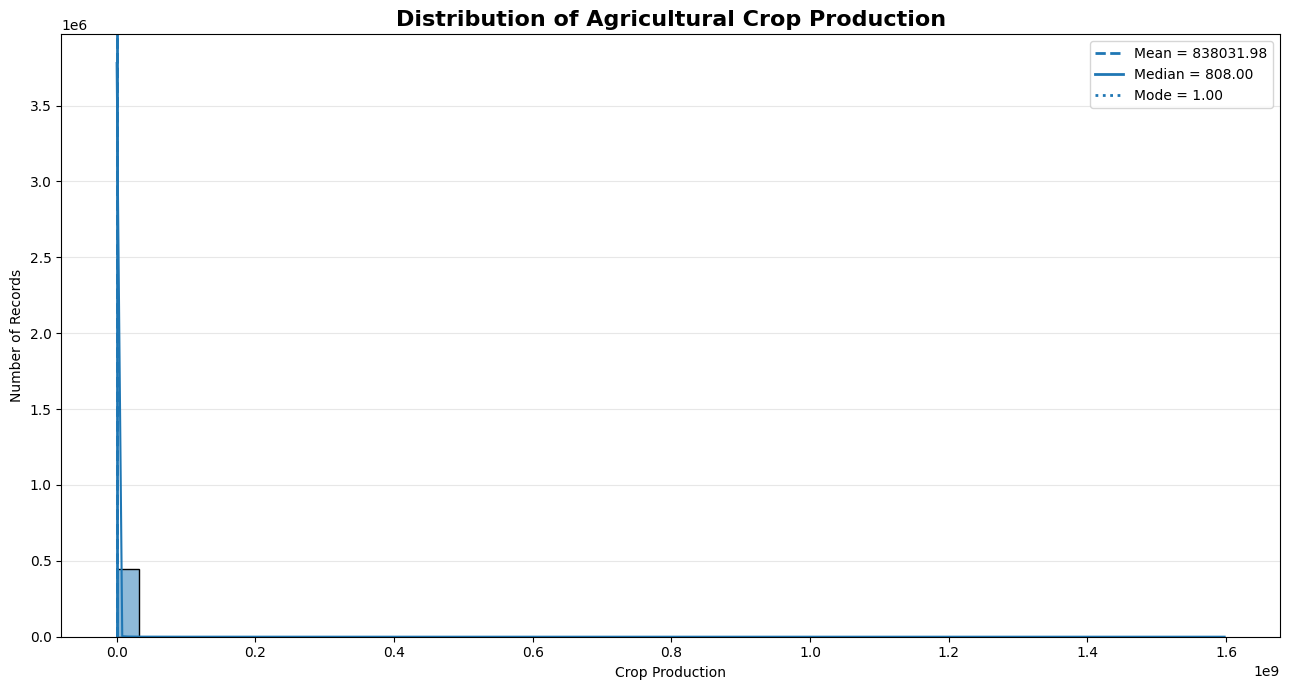

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select production data and remove missing values
production = df['production'].dropna()

# Calculate Mean, Median and Mode
mean_production = production.mean()
median_production = production.median()
mode_production = production.mode()[0]

# Display statistical values
print("Mean Production   :", round(mean_production, 2))
print("Median Production :", round(median_production, 2))
print("Mode Production   :", round(mode_production, 2))

# Create histogram
plt.figure(figsize=(13, 7))

sns.histplot(
    production,
    bins=50,
    kde=True
)

# Mean line
plt.axvline(
    mean_production,
    linestyle='--',
    linewidth=2,
    label=f"Mean = {mean_production:.2f}"
)

# Median line
plt.axvline(
    median_production,
    linestyle='-',
    linewidth=2,
    label=f"Median = {median_production:.2f}"
)

# Mode line
plt.axvline(
    mode_production,
    linestyle=':',
    linewidth=2,
    label=f"Mode = {mode_production:.2f}"
)

plt.title(
    "Distribution of Agricultural Crop Production",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Crop Production")
plt.ylabel("Number of Records")

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**

The histogram shows the distribution of crop production along with the mean, median and mode. These three statistical measures help us understand the central tendency of agricultural production.

**Key Insight**

The mean is considerably higher than the median, indicating that the production data is influenced by a number of very high production values.

# 2. Variance and Standard Deviation

Variance of Production         : 411526499931658.6
Standard Deviation of Production: 20286115.94


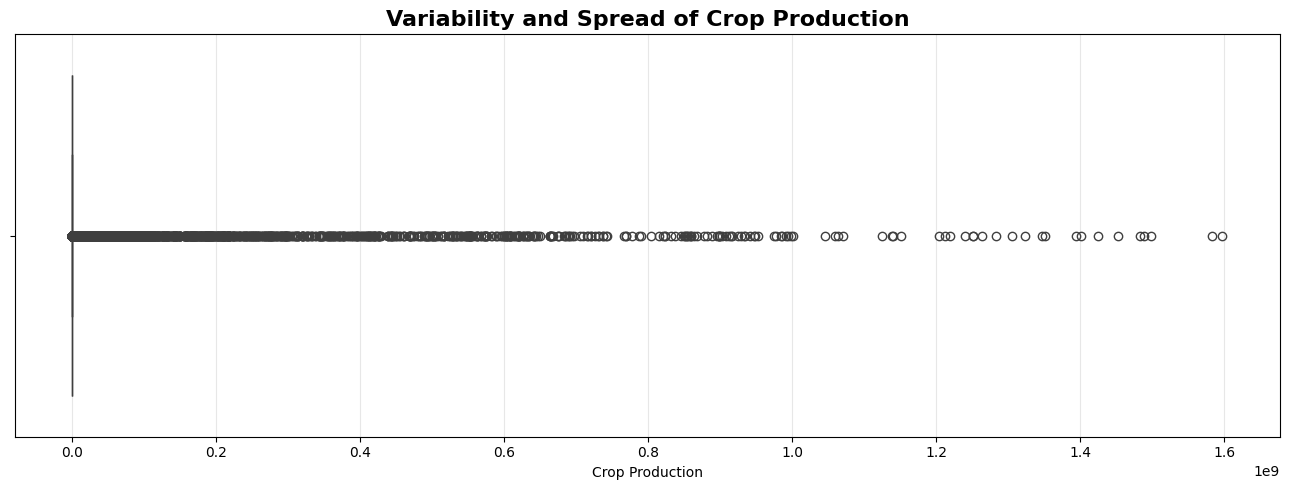

In [4]:
# Calculate Variance
variance_production = production.var()

# Calculate Standard Deviation
std_production = production.std()

print("Variance of Production         :", round(variance_production, 2))
print("Standard Deviation of Production:", round(std_production, 2))

# Create a boxplot
plt.figure(figsize=(13, 5))

sns.boxplot(
    x=production
)

plt.title(
    "Variability and Spread of Crop Production",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Crop Production")

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**

Variance and standard deviation measure how much the production values differ from the average production. The boxplot also helps visualize the spread and extreme production values.

**Key Insight**

The large spread in production indicates substantial variation between agricultural records.

**Observation**

Some crops and regions have much higher production than others, creating a wide variation in the dataset.

# 3.Skewness and Kurtosis


Skewness : 39.2647
Kurtosis : 1903.3535


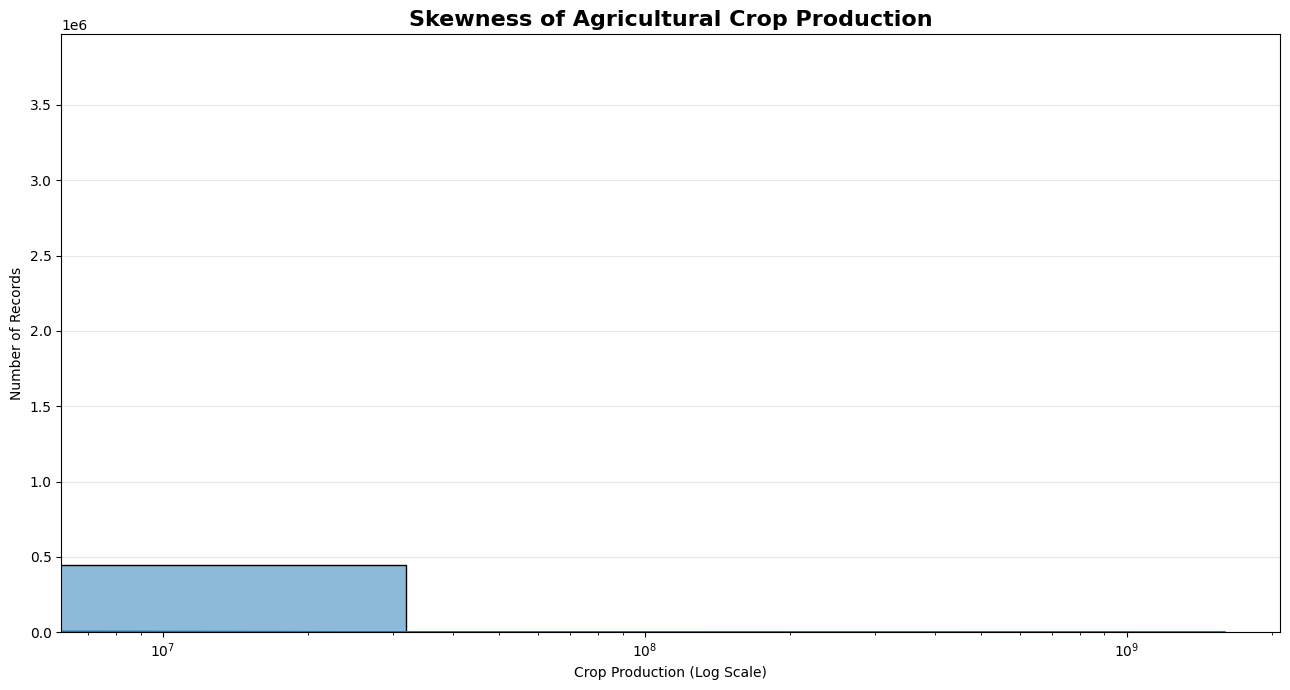

In [5]:
# Calculate Skewness
skewness_production = production.skew()

# Calculate Kurtosis
kurtosis_production = production.kurt()

print("Skewness :", round(skewness_production, 4))
print("Kurtosis :", round(kurtosis_production, 4))

# Plot distribution using log scale for better visibility
plt.figure(figsize=(13, 7))

sns.histplot(
    production,
    bins=50,
    kde=True
)

plt.xscale('log')

plt.title(
    "Skewness of Agricultural Crop Production",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Crop Production (Log Scale)")
plt.ylabel("Number of Records")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**

Skewness measures the asymmetry of the production distribution, while kurtosis indicates the presence and influence of extreme values.

**Key Insight**

The positive skewness indicates that the production distribution has a long right tail caused by records with very high production.

**Observation**

The production data is not normally distributed and contains extreme high-production observations.

# Statistical summary of Crop Production

In [6]:
statistical_summary = {
    "Mean": mean_production,
    "Median": median_production,
    "Mode": mode_production,
    "Variance": variance_production,
    "Standard Deviation": std_production,
    "Skewness": skewness_production,
    "Kurtosis": kurtosis_production
}

print("Statistical Summary of Crop Production")
print("--------------------------------------")

for measure, value in statistical_summary.items():
    print(f"{measure:<20}: {value:.4f}")

Statistical Summary of Crop Production
--------------------------------------
Mean                : 838031.9840
Median              : 808.0000
Mode                : 1.0000
Variance            : 411526499931658.6250
Standard Deviation  : 20286115.9400
Skewness            : 39.2647
Kurtosis            : 1903.3535


# PART 2 – UNIVARIATE ANALYSIS

**Meaning:**

Univariate analysis studies one variable at a time to understand its distribution and pattern.

# Univariate Analysis – Production Distribution
# 1. Production Distribution with Mean, Median and Mode

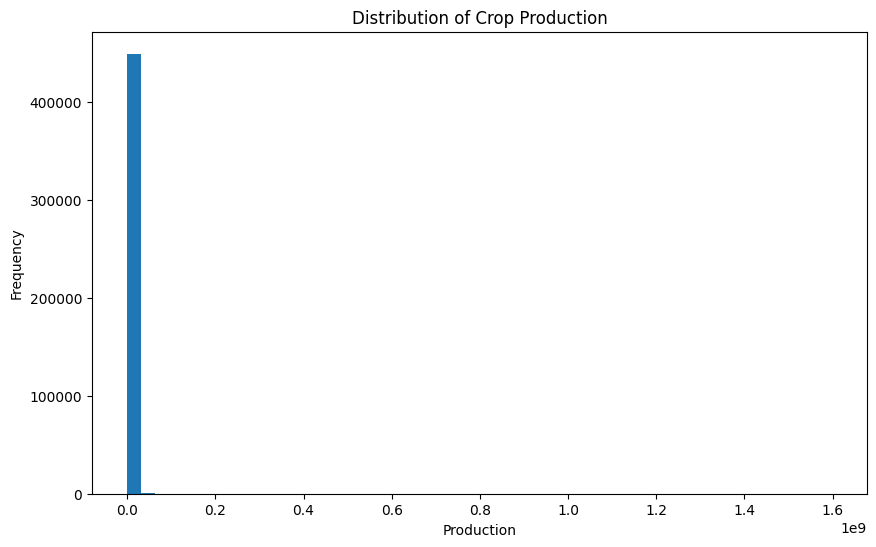

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(df['production'].dropna(), bins=50)

plt.title("Distribution of Crop Production")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

**What is it saying?**

The histogram shows how crop production values are distributed across the dataset.

**What features/columns did you use?**

I used the production column.

**What are you showing from this?**

This visualization shows that most production values are concentrated at lower levels, while a smaller number of records have very high production.

**Key Insight**

The production distribution is highly spread and influenced by a small number of very high production values.

# Univariate Analysis – Crop Type Distribution
# 2. Distribution of Crop Types

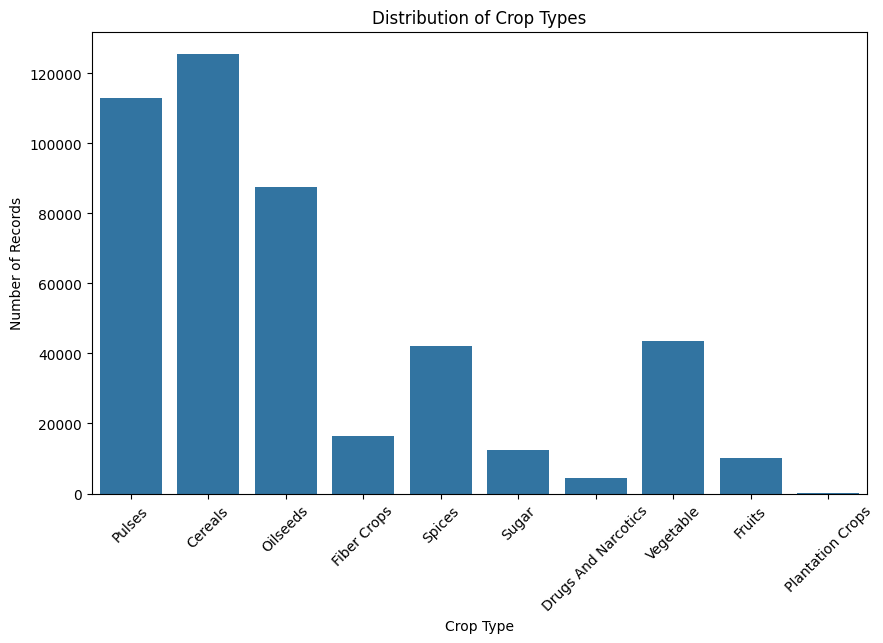

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.countplot(data=df, x='crop_type')

plt.title("Distribution of Crop Types")
plt.xlabel("Crop Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

**Interpretation of the above chart**

**What is it saying?**

The countplot shows the distribution of different crop types in the agricultural dataset.

**What features/columns did you use?**

I used the crop_type column to count the number of records for each crop category.

**What are you showing from this?**

This chart shows which crop types are more frequently represented in the dataset and helps us understand the overall composition of agricultural records.

**Key Insight**

Some crop types have more records than others, indicating different levels of representation in the dataset.

# Univariate Analysis – Season Distribution

# 3. Distribution of Agricultural Seasons

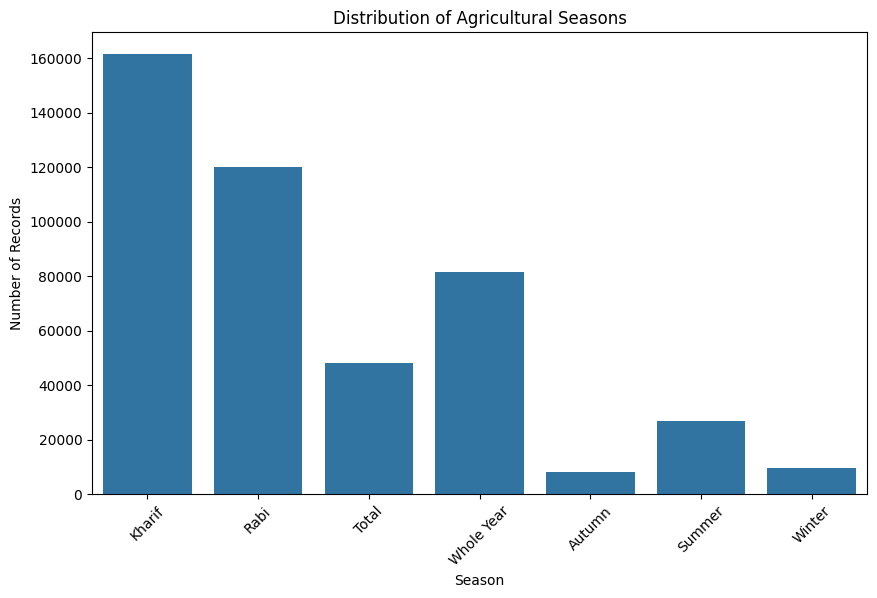

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x='season')

plt.title("Distribution of Agricultural Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

**Interpretation**

**What is it saying?**

The chart shows the number of agricultural records available for each season.

**What features/columns did you use?**

I used the season column.

**What are you showing from this?**

This helps us understand how the agricultural records are distributed across different seasons.

**Key Insight**

The number of records varies between seasons, showing that the dataset does not have equal representation for every season.

# PART 3 – BIVARIATE ANALYSIS

Meaning:

Bivariate analysis studies the relationship or comparison between two variables.

# Bivariate – Area vs Production
# 1. Area vs Production

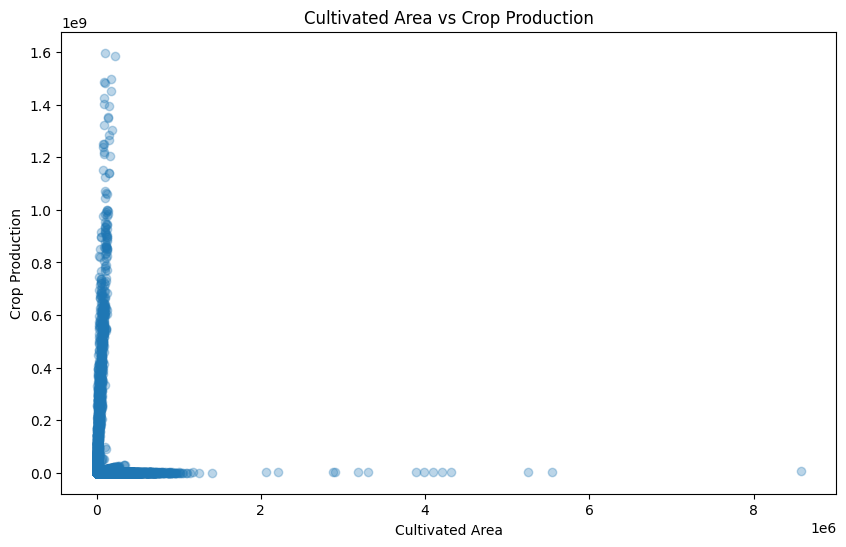

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['area'],
    df['production'],
    alpha=0.3
)

plt.title("Cultivated Area vs Crop Production")
plt.xlabel("Cultivated Area")
plt.ylabel("Crop Production")
plt.show()

**Interpretation**

**What is it saying?**

The scatter plot shows the relationship between cultivated area and crop production.

**What features/columns did you use?**

I used area and production columns.

**What are you showing from this?**

This chart helps us understand whether larger cultivated areas are associated with higher crop production.

**Key Insight**

Production generally varies with cultivated area, but the relationship is not the same for all agricultural records.

**Business Story**

This relationship can help in understanding how cultivated land contributes to agricultural output.

# Bivariate – Top 10 Crops by Production
# 2. Top 10 Crops by Total Production

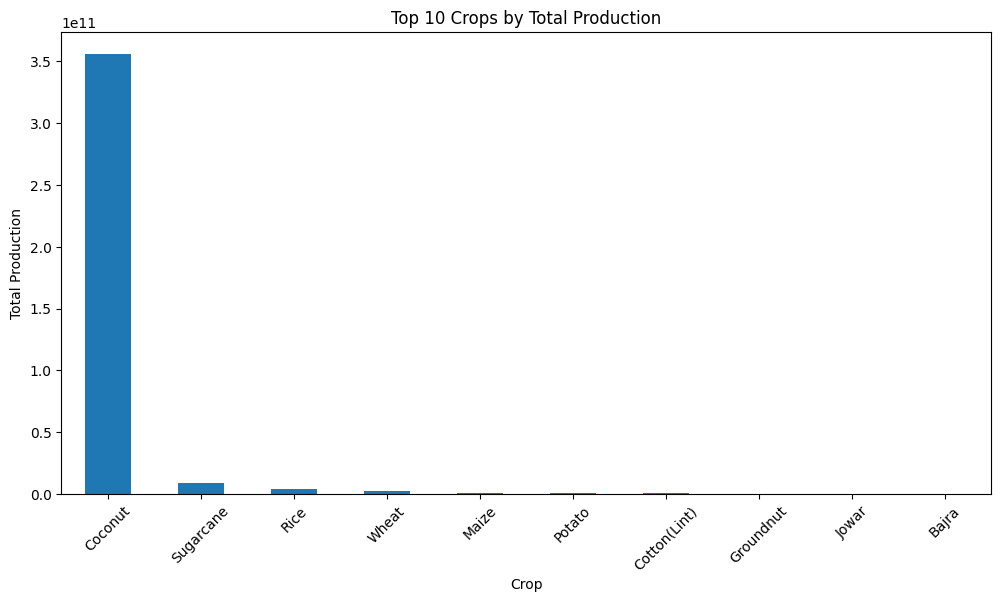

In [ ]:
top10_crops = (
    df.groupby('crop_name')['production']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top10_crops.plot(kind='bar')

plt.title("Top 10 Crops by Total Production")
plt.xlabel("Crop")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.show()

**Interpretation**

**What is it saying?**

The bar chart compares the total production of the top 10 crops in the dataset.

**What features/columns did you use?**

I used crop_name and production columns.

**What are you showing from this?**

This chart identifies the crops that contribute the most to overall agricultural production.

**Key Insight**

The chart shows that production is concentrated among a few major crops, with Coconut appearing as one of the major contributors in this dataset.

**Business Story**

Identifying major crops can help in agricultural resource allocation and production planning.

# Bivariate – Season vs Production
# 3. Total Production by Agricultural Season

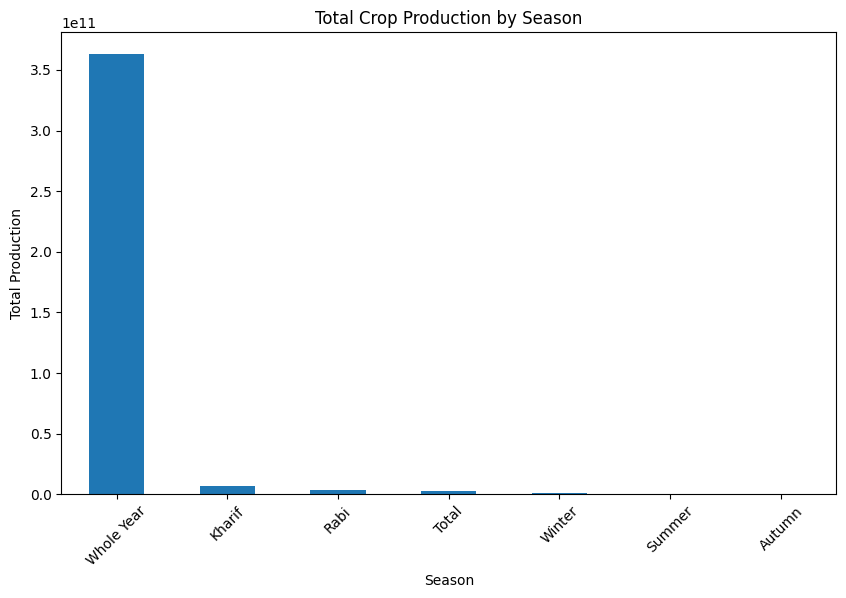

In [ ]:
season_production = (
    df.groupby('season')['production']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

season_production.plot(kind='bar')

plt.title("Total Crop Production by Season")
plt.xlabel("Season")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.show()

**Interpretation**

**What is it saying?**

The bar chart compares total crop production across different agricultural seasons.

**What features/columns did you use?**

I used season and production columns.

**What are you showing from this?**

This visualization shows which seasons contribute more or less to total agricultural production.

**Key Insight**

Production differs across seasons, indicating that seasonality plays an important role in agricultural production.

**Business Story**

Seasonal production patterns can help farmers and planners decide when to allocate resources and plan cultivation.

# PART 4 – MULTIVARIATE ANALYSIS

Meaning:

Multivariate analysis examines three or more variables together to identify deeper patterns and relationships.

# Multivariate – State + Crop + Production
# 1. State-wise and Crop-wise Production Analysis

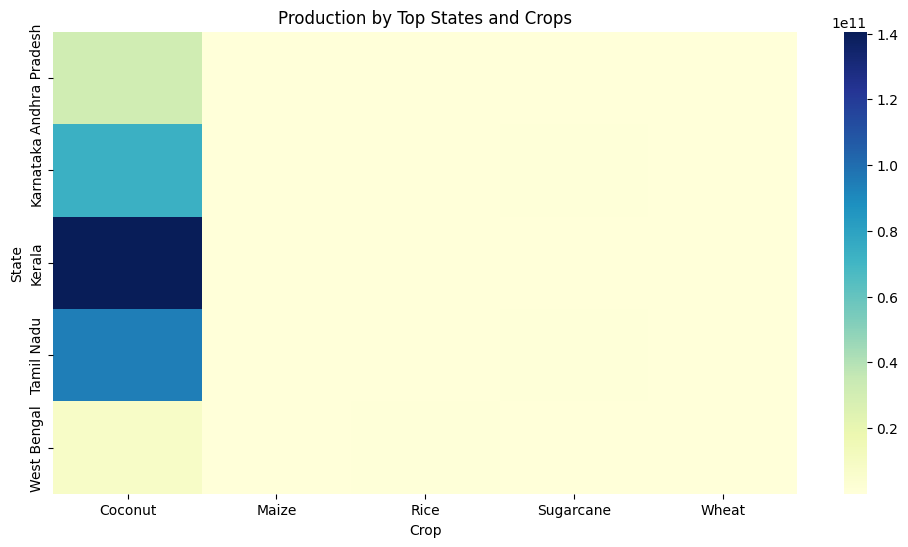

In [ ]:
top_states = (
    df.groupby('state_name')['production']
      .sum()
      .nlargest(5)
      .index
)

top_crops = (
    df.groupby('crop_name')['production']
      .sum()
      .nlargest(5)
      .index
)

temp = df[
    df['state_name'].isin(top_states) &
    df['crop_name'].isin(top_crops)
]

pivot_data = temp.pivot_table(
    values='production',
    index='state_name',
    columns='crop_name',
    aggfunc='sum'
)

plt.figure(figsize=(12,6))

sns.heatmap(pivot_data, annot=False, cmap='YlGnBu')

plt.title("Production by Top States and Crops")
plt.xlabel("Crop")
plt.ylabel("State")
plt.show()

**Interpretation**

**What is it saying?**

The heatmap compares production across different crops and major producing states.

**What features/columns did you use?**

I used state_name, crop_name and production.

**What are you showing from this?**

This visualization shows how production varies between different crops and states.

**Key Insight**

Different states have different crop production patterns, showing regional variation in agricultural output.

**Business Story**

This can help identify which crops perform strongly in particular states and support regional agricultural planning.

# Multivariate – Year + Season + Production
# 2. Year-wise Production by Season

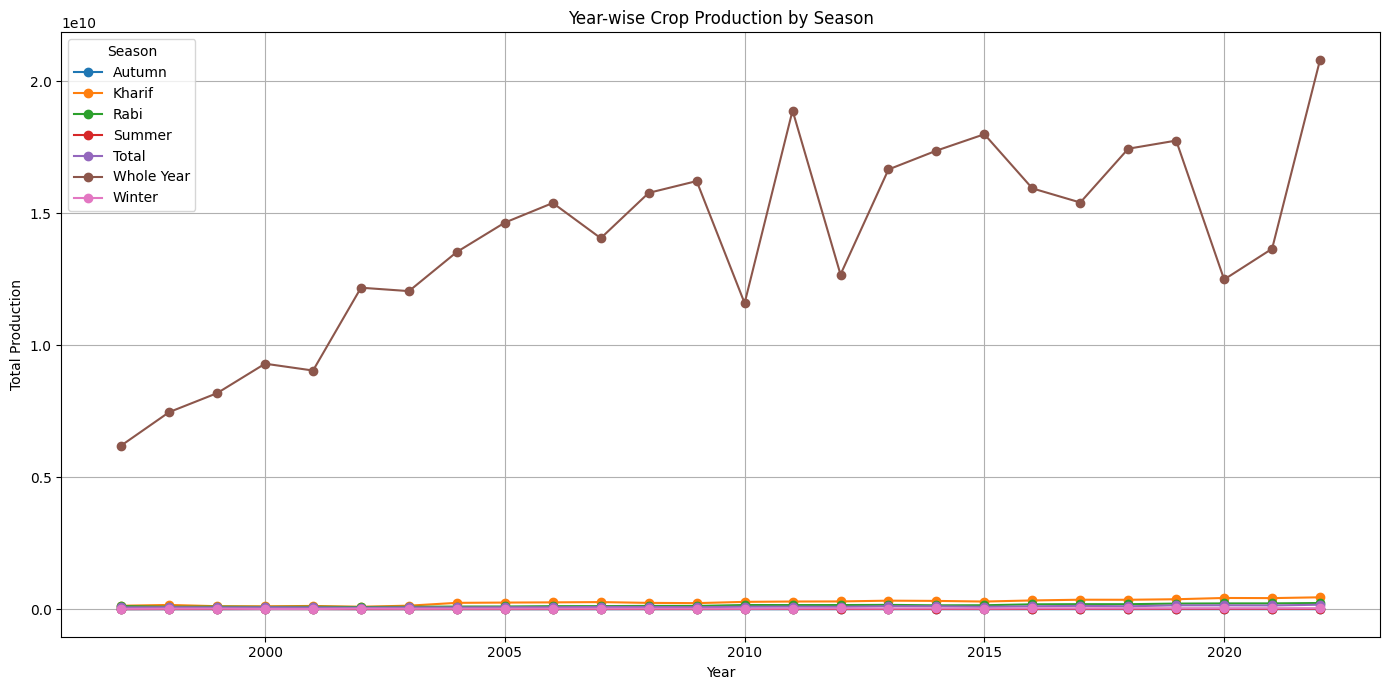

In [7]:
df['year_start'] = df['year'].astype(str).str[:4].astype(int)

year_season = df.pivot_table(
    values='production',
    index='year_start',
    columns='season',
    aggfunc='sum'
)

year_season.plot(
    kind='line',
    marker='o',
    figsize=(14, 7)
)

plt.title("Year-wise Crop Production by Season")
plt.xlabel("Year")
plt.ylabel("Total Production")
plt.legend(title="Season")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation**

**What is it saying?**
The line chart shows how total crop production changes across different years for different agricultural seasons.

**What features/columns did you use?**
I used year, season, and production.

**What are you showing from this?**
This chart helps identify increasing, decreasing, and fluctuating production patterns across different seasons over time.

**Key Insight**

Crop production varies across different years and seasons, showing that production does not remain constant over time.

**Business Story**

Understanding year-wise and season-wise production trends can help in agricultural planning, resource allocation, and future production forecasting.

# **Stage 4**


# **Documentation, Insights & Presentation**


Summary of Findings
Key Insights (3–5)


**Types of Analysis**

Descriptive Analysis

Diagnostic Analysis

Predictive Analysis

Prescriptive Analysis

**Recommendations / Decision Support**

Use a larger or more recent dataset for deeper insights

Automate parts of the analysis with scripts or dashboards

Extend the analysis to predictive modeling for forecasting if needed

# Step 1 – Final Dataset Summary

In [9]:
print("FINAL DATASET SUMMARY")
print("---------------------")

print("Total Records :", len(df))
print("Total Columns :", len(df.columns))
print("Total Crops   :", df['crop_name'].nunique())
print("Total States  :", df['state_name'].nunique())
print("Total Seasons :", df['season'].nunique())

print("Year Range    :", df['year'].min(), "to", df['year'].max())

FINAL DATASET SUMMARY
---------------------
Total Records : 455359
Total Columns : 17
Total Crops   : 115
Total States  : 34
Total Seasons : 7
Year Range    : 1997-1998 to 2022-2023


In [10]:
original_records = 455359
final_records = len(df)

records_removed = original_records - final_records
removed_percentage = (records_removed / original_records) * 100

print("Records Removed     :", records_removed)
print("Percentage Removed  :", round(removed_percentage, 2), "%")
print("Records Retained    :", round((final_records/original_records)*100, 2), "%")

Records Removed     : 0
Percentage Removed  : 0.0 %
Records Retained    : 100.0 %


# Step 2 – Summary of Findings

In [11]:
print("SUMMARY OF FINDINGS")
print("-------------------")

print("Total Records :", len(df))
print("Total Crops   :", df['crop_name'].nunique())
print("Total States  :", df['state_name'].nunique())
print("Total Seasons :", df['season'].nunique())

print("Mean Production   :", round(df['production'].mean(), 2))
print("Median Production :", round(df['production'].median(), 2))
print("Standard Deviation:", round(df['production'].std(), 2))
print("Skewness          :", round(df['production'].skew(), 2))

SUMMARY OF FINDINGS
-------------------
Total Records : 455359
Total Crops   : 115
Total States  : 34
Total Seasons : 7
Mean Production   : 838031.98
Median Production : 808.0
Standard Deviation: 20286115.94
Skewness          : 39.26


# Chart – Top 10 Crops by Production

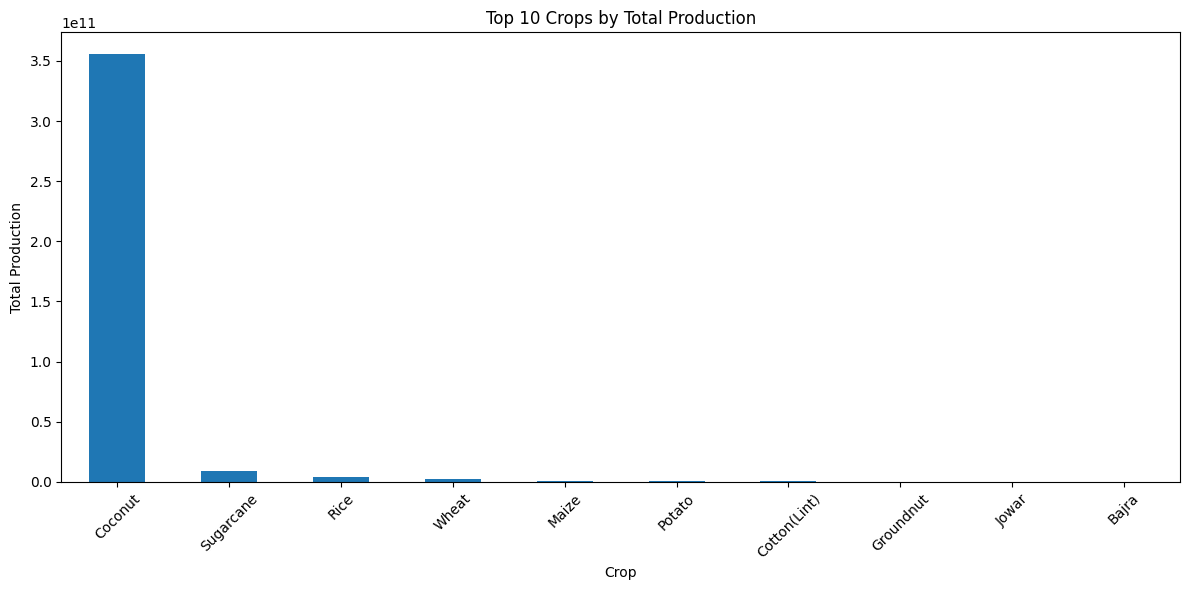

In [12]:
top_crops = (
    df.groupby('crop_name')['production']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
top_crops.plot(kind='bar')
plt.title("Top 10 Crops by Total Production")
plt.xlabel("Crop")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretation**

**What is it saying?**

The bar chart shows the top 10 crops based on their total production.

**What features/columns did you use?**

I used crop_name and production.

**What are you showing from this?**

This chart helps identify the crops that contribute the most to overall agricultural production.

**Key Insight**

Production is not equally distributed across all crops. Some crops contribute significantly more to total production than others.

**Business Story**

Identifying high-production crops can help in resource allocation, crop planning, storage management, and agricultural decision-making.

# Step 3 – Key Insights -5

**Insight 1 – Production Distribution**

The production data has a large variation between records. The mean is much higher than the median, indicating that some records have very high production values.

**Insight 2 – Production is Positively Skewed**

The production distribution is positively skewed because a smaller number of records have extremely high production values.

**Insight 3 – Crop-wise Variation**

Different crops contribute different levels of total production. A few crops contribute significantly more than others.

**Insight 4 – Seasonal Variation**

Crop production varies across agricultural seasons. This indicates that season plays an important role in production patterns.

**Insight 5 – Year-wise Variation**

Production changes across different years and seasons rather than remaining constant over time.

# Step 4 – Key Insights Chart

**Year-wise Production**

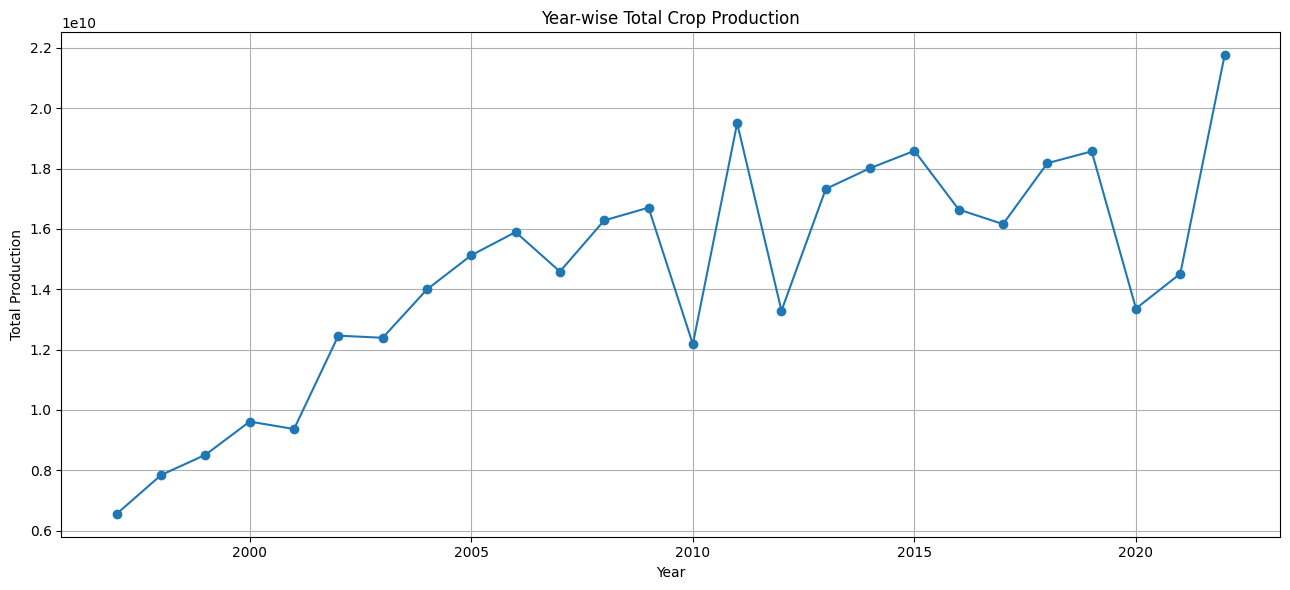

In [13]:
df['year_start'] = df['year'].astype(str).str[:4].astype(int)

year_production = (
    df.groupby('year_start')['production']
      .sum()
      .sort_index()
)

plt.figure(figsize=(13, 6))
plt.plot(year_production.index, year_production.values, marker='o')
plt.title("Year-wise Total Crop Production")
plt.xlabel("Year")
plt.ylabel("Total Production")
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation**

**What is it saying?**

The line chart shows how total agricultural production changes across different years.

**What features/columns did you use?**

I used year and production.

**What are you showing from this?**

The chart helps identify increasing, decreasing, and fluctuating production patterns over time.

**Key Insight**

Agricultural production changes over time and does not remain constant across all years.

**Business Story**

Historical production trends can support long-term agricultural planning and help identify years with higher or lower production.

# Step 5 – Types of Analysis


 Descriptive Analysis – What happened?

Diagnostic Analysis – Why did it happen?

Predictive Analysis – What may happen in the future?

Prescriptive Analysis – What should we do?

# 1. Descriptive Analysis

What happened?

In [19]:
print("Mean:", df['production'].mean())
print("Median:", df['production'].median())
print("Std:", df['production'].std())

Mean: 838031.9839505688
Median: 808.0
Std: 20286115.940013226


**Chart:** Production distribution / histogram

**Key Insight:**
Most production values are lower, while a few records have very high production.

**Business Story:**
Helps understand the overall production pattern.

# 2. Diagnostic Analysis

Why does production vary?

In [20]:
season_production = df.groupby('season')['production'].sum()
season_percentage = (season_production / season_production.sum()) * 100

print(round(season_percentage, 2))

season
Autumn         0.03
Kharif         1.85
Rabi           1.02
Summer         0.08
Total          0.69
Whole Year    96.16
Winter         0.19
Name: production, dtype: float64


**Chart:** Season-wise Production %

**Key Insight:**
Production contribution varies across different seasons.

**Business Story:**
Helps in seasonal planning and resource allocation.

# 3. Predictive Analysis

What may happen in the future?

In [21]:
df['year_start'] = df['year'].astype(str).str[:4].astype(int)

year_production = df.groupby('year_start')['production'].sum()
year_growth = year_production.pct_change() * 100

print(round(year_growth, 2))

year_start
1997      NaN
1998    19.59
1999     8.53
2000    12.93
2001    -2.57
2002    33.02
2003    -0.57
2004    12.93
2005     8.09
2006     5.07
2007    -8.22
2008    11.61
2009     2.60
2010   -27.08
2011    60.10
2012   -31.86
2013    30.38
2014     3.97
2015     3.19
2016   -10.46
2017    -2.90
2018    12.48
2019     2.16
2020   -28.05
2021     8.64
2022    49.85
Name: production, dtype: float64


**Chart:** Year-wise Production Growth %

**Key Insight:**
Historical trends can be used as a base for future forecasting.

# 4. Prescriptive Analysis

What should we do?

In [22]:
state_production = df.groupby('state_name')['production'].sum()
top_5 = state_production.sort_values(ascending=False).head(5)

percentage = (top_5.sum() / state_production.sum()) * 100
print("Top 5 States Share:", round(percentage, 2), "%")

Top 5 States Share: 93.58 %


**Chart:** Top 5 States Production Share

**Key Insight:**
Some states contribute more to overall production.

**Business Story:**
Resources, storage and transportation can be planned better in high-production regions.

# Recommendations / Decision Support

**Recommendation 1 – Focus on High-Production Crops**

Agricultural planning can prioritize high-production crops to improve resource allocation and storage planning.

**Recommendation 2 – Seasonal Planning**

Season-wise production trends can be used to plan seeds, fertilizers, irrigation, labor, and other agricultural resources.

**Recommendation 3 – High-Production States**

High-production states can be prioritized for storage, transportation, and supply-chain infrastructure.

**Recommendation 4 – Handle Extreme Values Carefully**

Extreme production values should not be removed automatically because they may represent genuine high-production records.

**Recommendation 5 – Improve Future Forecasting**

Historical production trends can be used to develop predictive models for future agricultural production forecasting.

# Recommendation Chart

In [23]:
state_production = (
    df.groupby('state_name')['production']
      .sum()
      .sort_values(ascending=False)
)

top_5_states = state_production.head(5)

top_5_percentage = (
    top_5_states.sum() / state_production.sum()
) * 100

print("Top 5 States Production Share:",
      round(top_5_percentage, 2), "%")

Top 5 States Production Share: 93.58 %


**Interpretation**

The top five states account for a measurable share of the total production in the dataset. This shows that production is concentrated in certain regions.

# Future Enhancement
**1. Larger or More Recent Dataset**

A larger and more recent dataset can be used to obtain deeper and more current agricultural insights.

**2. Automation**

The analysis can be automated using Python scripts and interactive dashboards, reducing manual effort and improving reporting efficiency.

**3. Predictive Modeling**

Machine learning and time-series models can be introduced to forecast future crop production.

**4. Advanced Dashboard**

“The analysis can be extended into an interactive dashboard using Power BI or Looker Studio for better decision support.”